In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks
from utils.graphs import media_movel, detectar_repeticoes_exercicio, plotar_grafico_angulos

# 1- Análise dados Flexão

In [ ]:
# Carregando dados de flexão
df_flexao = pd.read_csv('files_output/1_min_flexao_full_5fps_flexao.csv')
df_flexao

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,unknown,103.707314,0,Nose,0.459077,0.435132,-0.312750,0.999988,0.999986,True,flexao
1,0,0,0.0,unknown,103.707314,1,Left Eye (Inner),0.465022,0.424862,-0.284498,0.999978,0.999956,True,flexao
2,0,0,0.0,unknown,103.707314,2,Left Eye,0.466640,0.424740,-0.284394,0.999954,0.999942,True,flexao
3,0,0,0.0,unknown,103.707314,3,Left Eye (Outer),0.468016,0.424601,-0.284299,0.999972,0.999923,True,flexao
4,0,0,0.0,unknown,103.707314,4,Right Eye (Inner),0.456273,0.423066,-0.332812,0.999989,0.999977,True,flexao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9400,1710,285,57.0,unknown,56.828976,28,Right Ankle,0.485421,0.804235,0.363989,0.541251,0.999796,True,flexao
9401,1710,285,57.0,unknown,56.828976,29,Left Heel,0.869614,0.769929,-0.053025,0.951812,0.999151,True,flexao
9402,1710,285,57.0,unknown,56.828976,30,Right Heel,0.525913,0.811594,0.376794,0.672732,0.999771,True,flexao
9403,1710,285,57.0,unknown,56.828976,31,Left Foot Index,0.842612,0.820032,-0.220251,0.933408,0.998712,True,flexao


In [ ]:
# Transformar os landmarks em ângulos
df_angles_flexao = extract_angles_from_landmarks(df_flexao)
df_angles_flexao

,frame,timestamp_s,exercise,right_cotovelo,left_cotovelo,right_ombro,left_ombro,right_joelho,left_joelho,right_quadril,left_quadril
0,0,0.0,flexao,128.584808,139.259521,27.397871,24.300436,169.697235,157.981949,173.705383,175.946945
1,6,0.2,flexao,121.153587,126.631485,26.008823,22.457495,169.260345,159.688416,163.339676,178.812698
2,12,0.4,flexao,119.729301,124.277649,20.476686,21.540239,167.736481,166.848907,152.901764,179.325943
3,18,0.6,flexao,121.487328,120.263672,18.508518,19.302473,172.097092,164.991394,151.328003,176.548660
4,24,0.8,flexao,124.188545,128.551895,11.297976,28.815027,170.088318,170.836975,141.970261,177.220596
...,...,...,...,...,...,...,...,...,...,...,...
280,1686,56.2,flexao,164.583160,173.100388,74.161568,76.917709,170.096024,171.809250,166.015442,166.627075
281,1692,56.4,flexao,168.675064,169.748856,84.469620,90.747726,78.255730,176.610886,80.515869,158.313705
282,1698,56.6,flexao,167.293961,178.800720,94.568420,104.918297,48.210514,173.696167,26.332941,152.670334
283,1704,56.8,flexao,171.753220,175.091873,100.722198,108.664879,56.309628,171.141602,28.381361,149.040192


## Análise ângulos dos cotovelos e joelhos durante a flexão

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_flexao_mm3= media_movel(df_angles_flexao, janela=3)
df_angles_flexao_mm3 = df_angles_flexao_mm3[df_angles_flexao_mm3['timestamp_s'] <= 30]

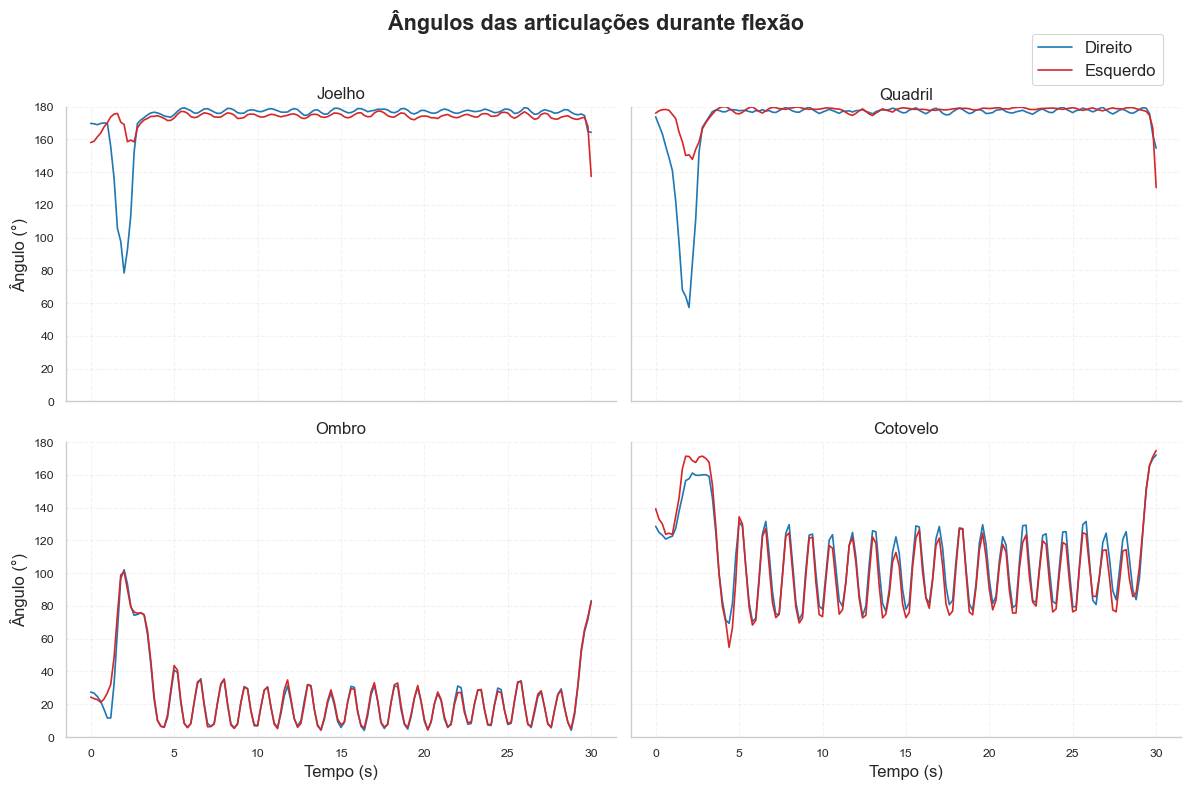

In [ ]:
# Plotando os ângulos das articulações durante a flexão
plotar_grafico_angulos(df_angles_flexao_mm3, 'Ângulos das articulações durante flexão', articulacoes=('joelho', 'quadril', 'ombro', 'cotovelo'), fonte=12)

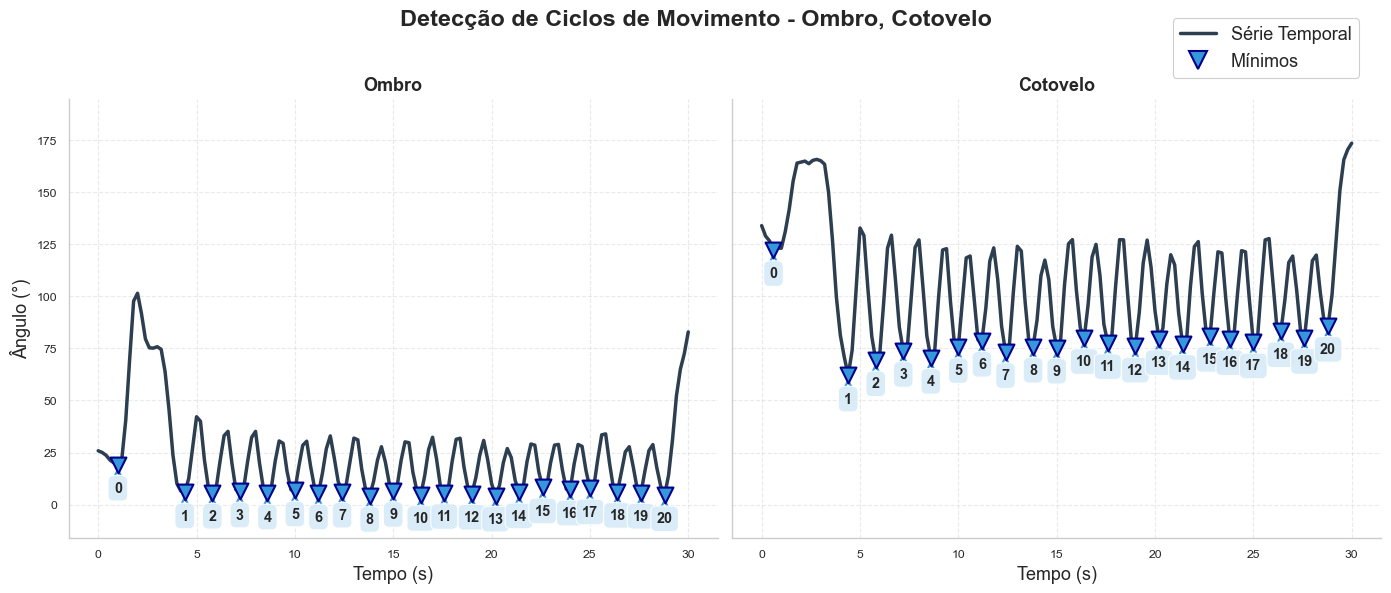

In [ ]:
# Utilizando método de detecção de repetições baseado em vales para contagem das repetições de flexão
detectar_repeticoes_exercicio(
    df_angles_flexao_mm3,
    articulacoes=['ombro', 'cotovelo'],
    tipo_deteccao='vales',
    fontsize=13
)

# 2- Análise dados Agachamento

In [ ]:
# Carregando dados de agachamento
df_agachamento = pd.read_csv('files_output/2_min_agachamento_full_5fps_agachamento.csv')
df_agachamento

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,full,117.153406,0,Nose,0.666536,0.456063,0.016429,0.999134,0.999648,True,agachamento
1,0,0,0.0,full,117.153406,1,Left Eye (Inner),0.664845,0.443492,0.041082,0.998299,0.999473,True,agachamento
2,0,0,0.0,full,117.153406,2,Left Eye,0.663011,0.442395,0.040946,0.997703,0.999451,True,agachamento
3,0,0,0.0,full,117.153406,3,Left Eye (Outer),0.660651,0.441109,0.040856,0.998684,0.999395,True,agachamento
4,0,0,0.0,full,117.153406,4,Right Eye (Inner),0.662927,0.443361,-0.043401,0.998670,0.999558,True,agachamento
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29266,5316,886,177.2,full,91.052771,28,Right Ankle,0.617585,0.930344,-0.137959,0.987676,0.994421,True,agachamento
29267,5316,886,177.2,full,91.052771,29,Left Heel,0.602672,0.923288,0.432787,0.603585,0.984643,True,agachamento
29268,5316,886,177.2,full,91.052771,30,Right Heel,0.589472,0.951892,-0.138576,0.975081,0.990505,True,agachamento
29269,5316,886,177.2,full,91.052771,31,Left Foot Index,0.704106,0.924245,0.337296,0.679852,0.986353,True,agachamento


In [ ]:
# Transformar os landmarks em ângulos
df_angles_agachamento = extract_angles_from_landmarks(df_agachamento)
df_angles_agachamento

,frame,timestamp_s,exercise,right_cotovelo,left_cotovelo,right_ombro,left_ombro,right_joelho,left_joelho,right_quadril,left_quadril
0,0,0.0,agachamento,174.871063,170.758682,94.881927,93.751190,150.655762,154.374283,138.079391,140.585342
1,6,0.2,agachamento,172.316818,171.951553,91.277374,92.336212,154.900421,156.383835,143.523315,143.650360
2,12,0.4,agachamento,168.092224,168.856003,88.463470,88.667328,160.427002,157.616623,152.041367,148.065277
3,18,0.6,agachamento,172.340027,168.281738,89.869965,87.535477,162.453156,160.681839,158.449249,151.469467
4,24,0.8,agachamento,175.401291,175.057861,91.461243,89.946930,162.328659,162.432404,158.741455,156.151123
...,...,...,...,...,...,...,...,...,...,...,...
882,5292,176.4,agachamento,177.420395,173.910599,114.195892,116.490372,123.182617,130.651733,94.508064,94.915695
883,5298,176.6,agachamento,178.763916,173.710571,103.083572,104.845230,141.037796,147.332550,122.505913,125.628456
884,5304,176.8,agachamento,171.930252,171.202850,85.092468,92.805077,144.679184,155.396072,141.009735,142.981567
885,5310,177.0,agachamento,146.913223,161.849655,37.579388,41.664417,151.780579,160.764130,161.174835,163.498672


## Análise ângulos dos joelhos e quadril durante o agachamento

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_agachamento_mm3= media_movel(df_angles_agachamento, janela=3)
df_angles_agachamento_mm3 = df_angles_agachamento_mm3[df_angles_agachamento_mm3['timestamp_s'] <= 60]

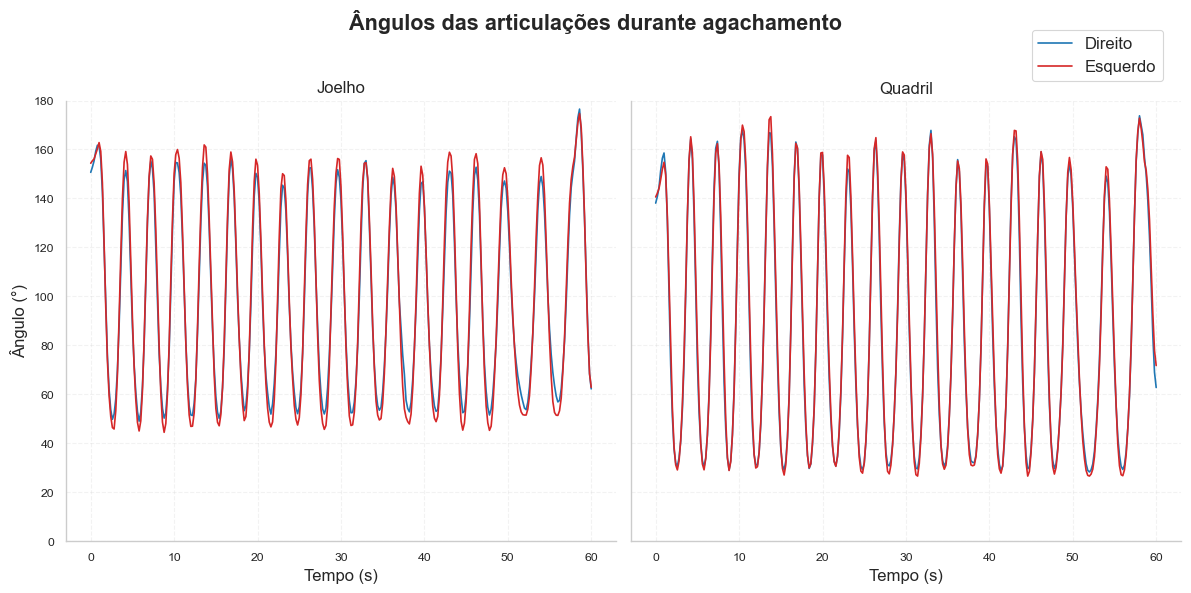

In [ ]:
# Plotando os ângulos das articulações de joelho e quadril durante o agachamento
plotar_grafico_angulos(df_angles_agachamento_mm3, 'Ângulos das articulações durante agachamento', articulacoes=['joelho', 'quadril'], fonte = 12)

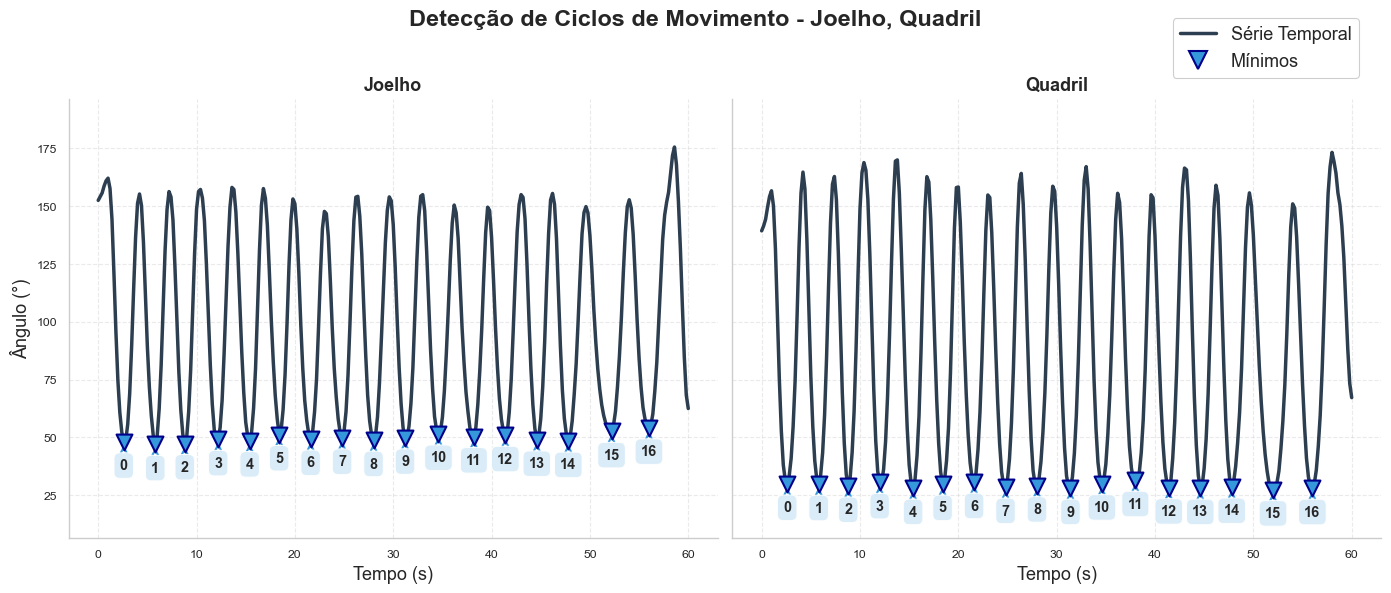

In [ ]:
# Utilizando método de detecção de repetições baseado em vales para contagem das repetições de agachamento
detectar_repeticoes_exercicio(
    df_angles_agachamento_mm3,
    articulacoes=['joelho', 'quadril'],
    tipo_deteccao='vales',
    fontsize=13
)

# 3- Análise dados Rosca Direta

In [ ]:
# Carregando dados de rosca direta
df_rosca = pd.read_csv('files_output\\2_min_rosca_direta_full_5fps_rosca_biceps.csv')
df_rosca

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,full,118.573427,0,Nose,0.624339,0.440246,-0.010436,0.998963,0.999064,True,rosca_biceps
1,0,0,0.0,full,118.573427,1,Left Eye (Inner),0.616982,0.429392,0.014296,0.997450,0.998730,True,rosca_biceps
2,0,0,0.0,full,118.573427,2,Left Eye,0.615667,0.429143,0.014269,0.997099,0.998626,True,rosca_biceps
3,0,0,0.0,full,118.573427,3,Left Eye (Outer),0.614024,0.428888,0.014332,0.997708,0.998478,True,rosca_biceps
4,0,0,0.0,full,118.573427,4,Right Eye (Inner),0.612444,0.429056,-0.054389,0.998196,0.999049,True,rosca_biceps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19894,3612,602,120.4,full,42.149782,28,Right Ankle,0.535403,0.953828,-0.283861,0.944775,0.981641,True,rosca_biceps
19895,3612,602,120.4,full,42.149782,29,Left Heel,0.523958,0.933573,0.362183,0.562871,0.963719,True,rosca_biceps
19896,3612,602,120.4,full,42.149782,30,Right Heel,0.514786,0.972706,-0.295832,0.915740,0.966771,True,rosca_biceps
19897,3612,602,120.4,full,42.149782,31,Left Foot Index,0.636521,0.950084,0.267892,0.662191,0.968833,True,rosca_biceps


In [ ]:
# Transformar os landmarks em ângulos
df_angles_rosca = extract_angles_from_landmarks(df_rosca)
df_angles_rosca

,frame,timestamp_s,exercise,right_cotovelo,left_cotovelo,right_ombro,left_ombro,right_joelho,left_joelho,right_quadril,left_quadril
0,0,0.0,rosca_biceps,142.350632,148.606232,0.236563,1.499200,179.638992,174.950058,168.665894,166.321396
1,6,0.2,rosca_biceps,143.467804,153.820251,0.019782,2.758892,179.767609,171.758698,169.282944,170.637589
2,12,0.4,rosca_biceps,146.574615,147.459793,2.014894,0.367441,178.634552,168.288025,169.772141,174.724808
3,18,0.6,rosca_biceps,145.500336,145.268906,2.722107,1.165333,175.382584,131.564285,171.995926,168.624313
4,24,0.8,rosca_biceps,145.836929,150.820526,2.046027,4.054343,174.798920,159.766968,170.005005,174.187546
...,...,...,...,...,...,...,...,...,...,...,...
598,3588,119.6,rosca_biceps,145.710007,143.309433,36.460606,29.004539,177.572144,175.486801,170.319473,168.546387
599,3594,119.8,rosca_biceps,131.448029,140.245636,27.081007,11.115085,178.244186,178.881088,160.409760,167.388840
600,3600,120.0,rosca_biceps,115.075264,141.038101,15.827371,5.098813,176.239838,173.697281,167.416458,175.462738
601,3606,120.2,rosca_biceps,119.209251,139.492584,11.867986,0.362077,178.854294,173.543533,176.610703,177.361053


## Análise ângulos articulações durante o exercício rosca direta

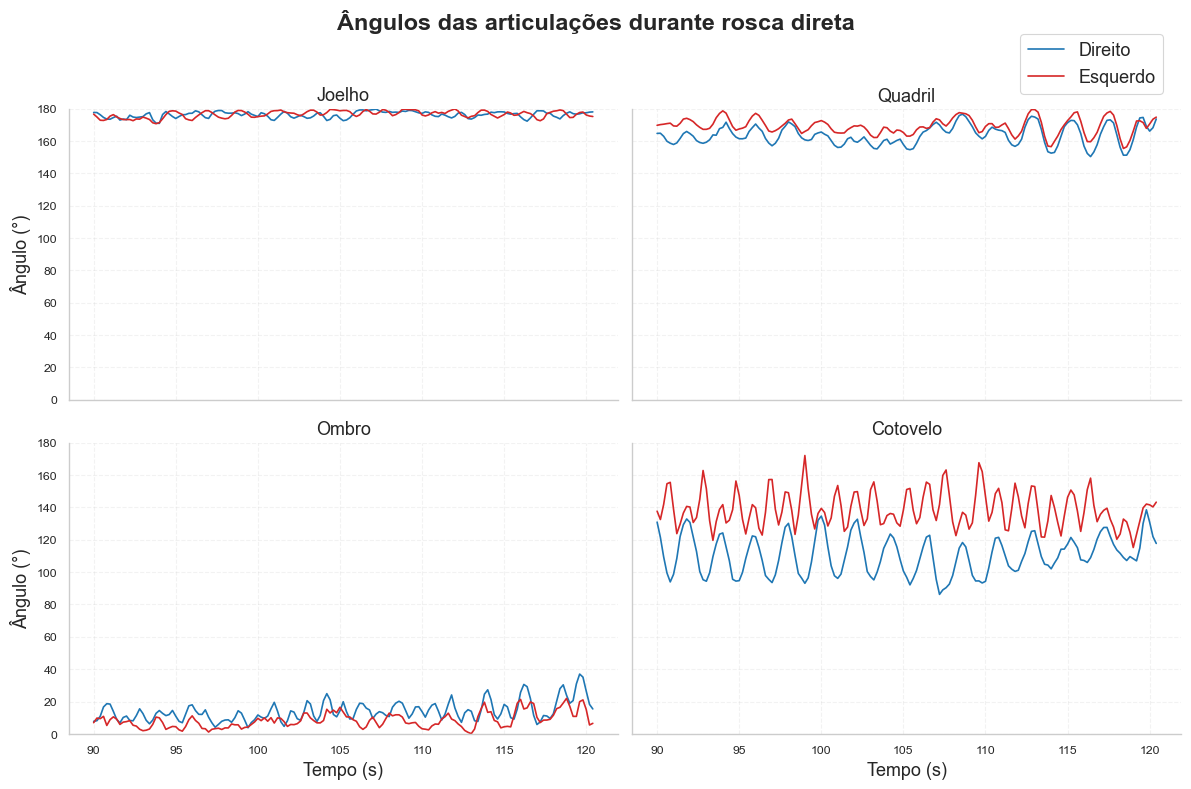

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_rosca_mm3= media_movel(df_angles_rosca, janela=3)
# df_angles_rosca_mm3 = df_angles_rosca_mm3[(df_angles_rosca_mm3['timestamp_s']  >= 50) & (df_angles_rosca_mm3['timestamp_s'] <= 90)]
# df_angles_rosca_mm3 = df_angles_rosca_mm3[(df_angles_rosca_mm3['timestamp_s']  <= 50)]
df_angles_rosca_mm3 = df_angles_rosca_mm3[(df_angles_rosca_mm3['timestamp_s']  >= 90)]

# Plotando os ângulos das articulações de Joelho e Quadril, Ombro, Cotovelo durante a rosca direta
plotar_grafico_angulos(df_angles_rosca_mm3, 'Ângulos das articulações durante rosca direta', fonte = 13)


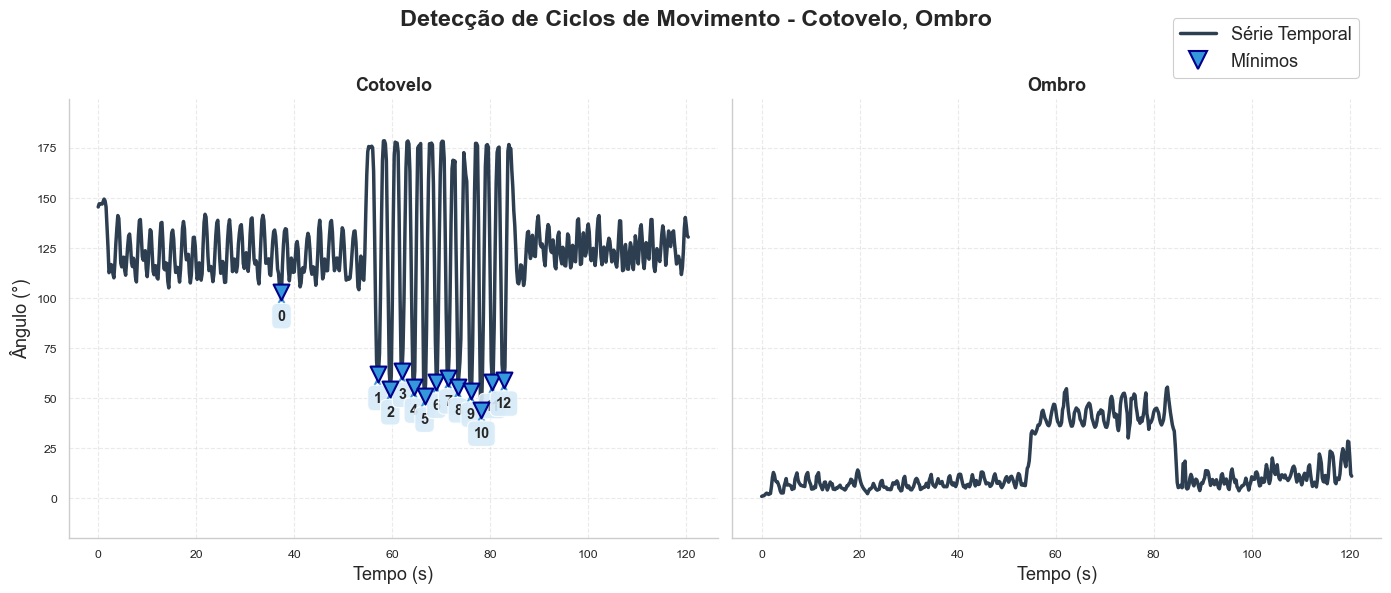

In [ ]:
# Utilizando método de detecção de repetições baseado em vales para contagem das repetições de rosca direta
detectar_repeticoes_exercicio(
    df_angles_rosca_mm3,
    articulacoes=['cotovelo', 'ombro'],
    tipo_deteccao='vales',
    prominence_vales=40,
    fontsize=13
)

# 3- Análise dados Descanso

In [ ]:
# Carregando dados de descanso
df_descanso = pd.read_csv('files_output/2_min_descanso_full_5fps_descanso.csv')
df_descanso

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,full,121.725082,0,Nose,0.673387,0.713010,-0.323280,0.999923,0.999983,True,descanso
1,0,0,0.0,full,121.725082,1,Left Eye (Inner),0.693016,0.711047,-0.314178,0.999813,0.999976,True,descanso
2,0,0,0.0,full,121.725082,2,Left Eye,0.694996,0.710166,-0.314337,0.999883,0.999976,True,descanso
3,0,0,0.0,full,121.725082,3,Left Eye (Outer),0.697096,0.709105,-0.314493,0.999826,0.999977,True,descanso
4,0,0,0.0,full,121.725082,4,Right Eye (Inner),0.691319,0.709918,-0.368688,0.999829,0.999977,True,descanso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23557,4284,714,142.8,full,75.824499,28,Right Ankle,0.614524,0.927282,-0.234590,0.982340,0.991370,True,descanso
23558,4284,714,142.8,full,75.824499,29,Left Heel,0.594048,0.925913,0.226453,0.586735,0.985855,True,descanso
23559,4284,714,142.8,full,75.824499,30,Right Heel,0.591856,0.947165,-0.240835,0.965254,0.984979,True,descanso
23560,4284,714,142.8,full,75.824499,31,Left Foot Index,0.704363,0.929061,0.109588,0.695993,0.986439,True,descanso


In [ ]:
# Transformar os landmarks em ângulos
df_angles_descanso = extract_angles_from_landmarks(df_descanso)
df_angles_descanso

,frame,timestamp_s,exercise,right_cotovelo,left_cotovelo,right_ombro,left_ombro,right_joelho,left_joelho,right_quadril,left_quadril
0,0,0.0,descanso,144.029205,165.533447,99.985451,97.560112,158.480774,82.817360,133.462891,29.924885
1,6,0.2,descanso,143.130737,174.696289,60.396629,96.198494,154.993164,107.955246,130.468033,43.493919
2,12,0.4,descanso,154.031555,178.824631,38.651173,59.141354,151.553391,156.711258,103.789986,84.901970
3,18,0.6,descanso,130.025208,157.952454,45.106201,48.320667,142.278961,178.628967,108.702950,94.227554
4,24,0.8,descanso,119.194702,158.065964,90.848122,80.406059,142.913864,139.187149,91.874153,118.128593
...,...,...,...,...,...,...,...,...,...,...,...
709,4260,142.0,descanso,124.656570,112.989586,18.255945,9.189813,149.998856,152.021637,109.945763,109.823692
710,4266,142.2,descanso,132.039902,114.912407,37.274025,26.419275,145.697220,151.884262,118.692917,120.901527
711,4272,142.4,descanso,149.417801,134.811920,50.689770,38.698341,152.788651,152.179810,141.017929,137.628418
712,4278,142.6,descanso,158.358414,144.778671,52.094448,40.871613,158.843964,156.894928,159.510223,155.915100


## Análise ângulos articulações durante o exercício rosca direta

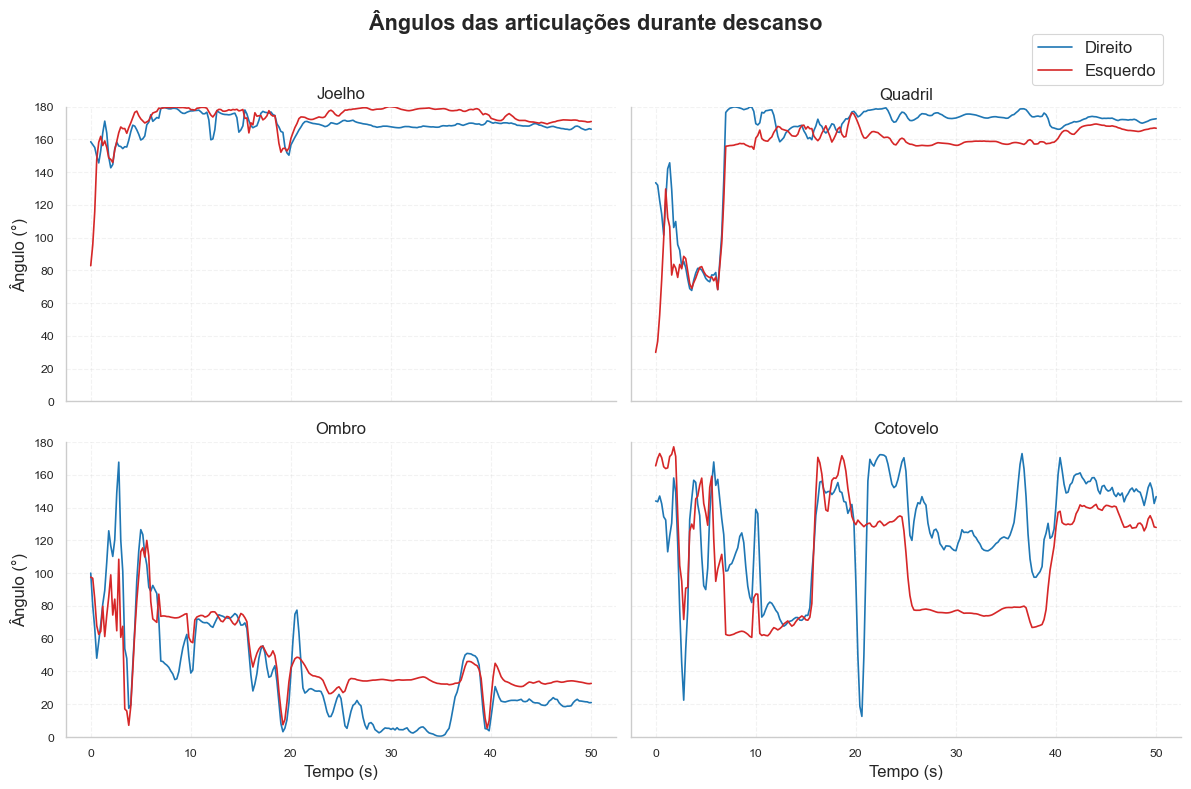

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_descanso_mm3= media_movel(df_angles_descanso, janela=3)
df_angles_descanso_mm3 = df_angles_descanso_mm3[df_angles_descanso_mm3['timestamp_s'] <= 50]

# Plotando os ângulos das articulações durante descanso
plotar_grafico_angulos(df_angles_descanso_mm3, 'Ângulos das articulações durante descanso', fonte = 12)
